# Regression

---

### Learning Methods

**Supervised** learning: data with labels

**Unsupervised** learning: data *without* labels => learn unclear patterns

Regression is a method of *supervised* learning

### Regression Types

**Linear** regression: predicts *continuous numerical value* using linear relationship between $X = [x_1, ..., x_i]$ and $y$: $y = AX + β_0$

**Logistic** regression: predicts *category (0 / 1)* or *probabilities* $p$: 
$$p = \frac{1}{1 + e^{-z}}, \: z = AX + β_0$$
$p$ is calculated using the *sigmoid* function and ranges between 0 and 1

probabilities can be converted to classification using a threshold: `return 1 if p > threshold else 0`

In [326]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc, r2_score
import numpy as np
from matplotlib.patches import Rectangle

## Logistic Regression

---

In [327]:
REPO_ROOT = Path.cwd().parents[1]
DATA_DIR = REPO_ROOT / "data"

RANDOM_SEED = 42
TEST_RATIO = 0.2
THRESHOLD = 0.5

In [328]:
label_font = {
    "family": "Times New Roman",
    "size": 15,
}
title_font = {
    "family": "Times New Roman",
    "size": 18,
    "weight": "bold",
}
background_color = "lightgray"
edge_color = "darkgray"

#### Dataset Overview

In [329]:
df = pd.read_csv(DATA_DIR / "framingham.csv")
df = df.drop(columns=["id"])
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000
mean,0.443685,49.551941,1.980317,0.489065,9.025424,0.030344,0.005741,0.311646,0.027064,236.847731,132.370558,82.917031,25.782802,75.730727,81.852925,0.152269
std,0.496886,8.562029,1.022656,0.499949,11.921590,0.171557,0.075561,0.463229,0.162292,44.097681,22.086866,11.974258,4.065601,11.981525,23.904164,0.359331
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,113.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.080000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.380000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,143.875000,90.000000,28.037500,82.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,600.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


C:\Users\chris\AppData\Local\Temp\ipykernel_19152\3926200753.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax=ax)


array([[<Axes: title={'center': 'male'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'education'}>,
        <Axes: title={'center': 'currentSmoker'}>],
       [<Axes: title={'center': 'cigsPerDay'}>,
        <Axes: title={'center': 'BPMeds'}>,
        <Axes: title={'center': 'prevalentStroke'}>,
        <Axes: title={'center': 'prevalentHyp'}>],
       [<Axes: title={'center': 'diabetes'}>,
        <Axes: title={'center': 'totChol'}>,
        <Axes: title={'center': 'sysBP'}>,
        <Axes: title={'center': 'diaBP'}>],
       [<Axes: title={'center': 'BMI'}>,
        <Axes: title={'center': 'heartRate'}>,
        <Axes: title={'center': 'glucose'}>,
        <Axes: title={'center': 'TenYearCHD'}>]], dtype=object)

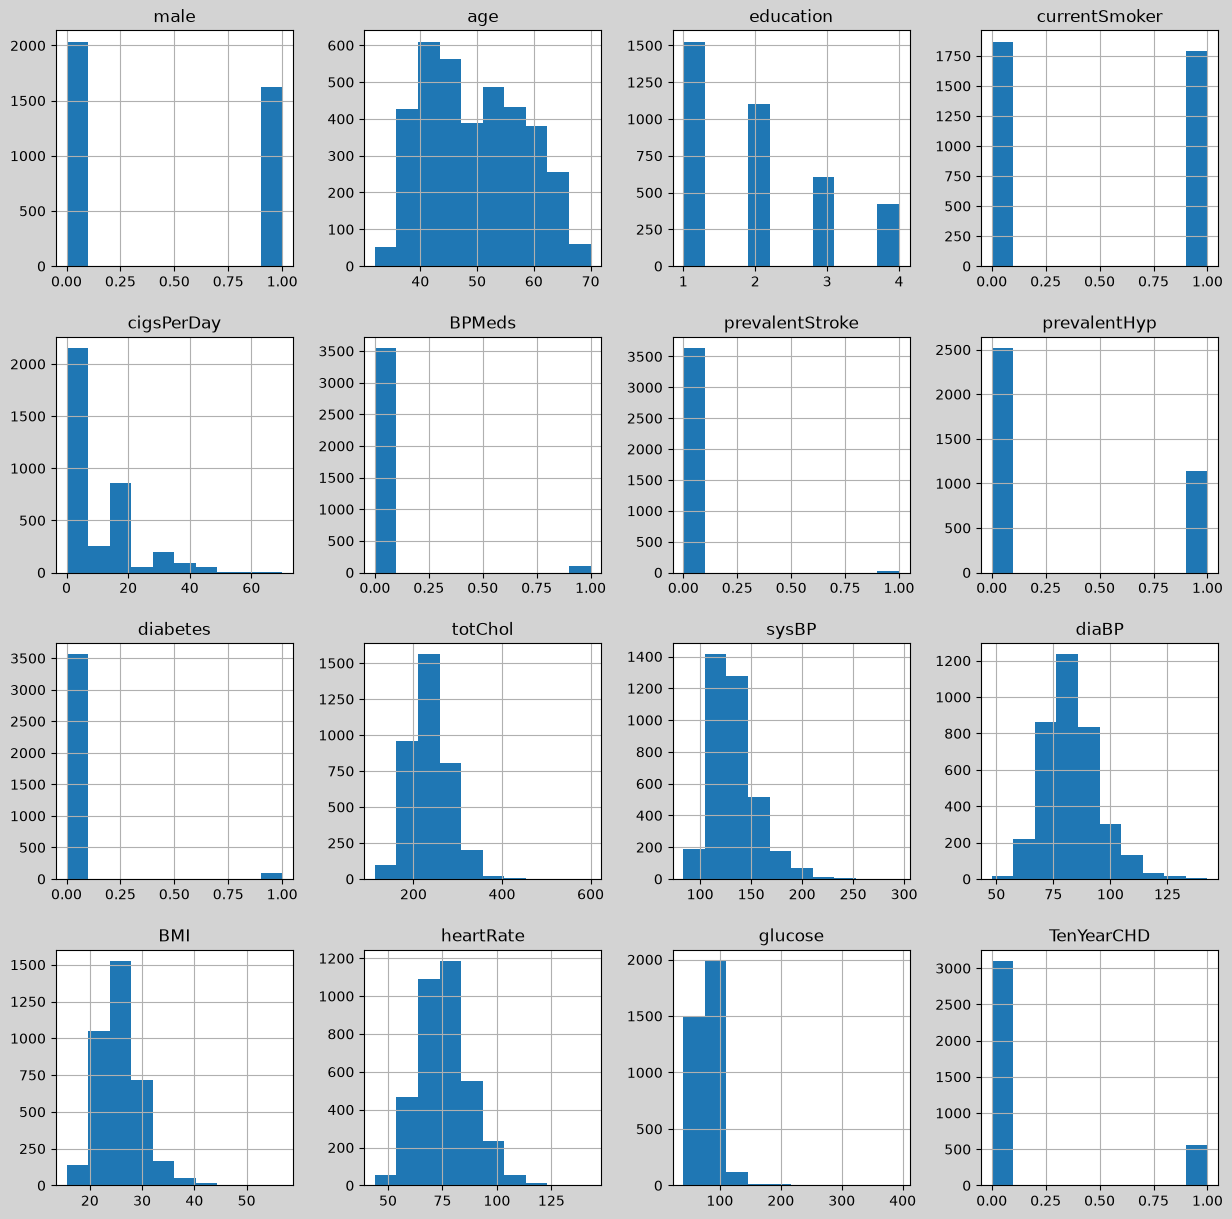

In [330]:
fig = plt.figure(figsize=(15, 15), facecolor=background_color)
ax = fig.gca()
plt.tight_layout()
df.hist(ax=ax)

### Baseline Model

The baseline model predicts always the most frequent value.
It is used to check if the model's accuracy is actually good.

<Axes: >

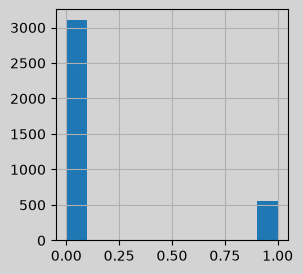

In [331]:
plt.figure(figsize=(3, 3), facecolor=background_color)
plt.gca().set_facecolor(background_color)
df["TenYearCHD"].hist()

In [332]:
df["TenYearCHD"].value_counts()

TenYearCHD
0    3101
1     557
Name: count, dtype: int64

#### Baseline Model accuracy

Always predicts 0:

$accuracy = \frac{3101}{3101+557} \approx 0.84773$ 

So we should aim for accuracy above that

In [333]:
train_data, test_data = train_test_split(
    df, test_size=TEST_RATIO, random_state=RANDOM_SEED
)

log_model = sm.formula.glm(  # generalized linear model
    formula=f"TenYearCHD ~ {' + '.join(df.columns.drop('TenYearCHD'))}",
    family=sm.families.Binomial(),  # target is binary (0/1)
    data=train_data,
).fit()

print(log_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             TenYearCHD   No. Observations:                 2926
Model:                            GLM   Df Residuals:                     2910
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1085.5
Date:                Fri, 18 Sep 2026   Deviance:                       2171.0
Time:                        14:06:55   Pearson chi2:                 2.89e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.09408
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -8.7718      0.812    -

#### Summary explanation

- *Dep. Variable: Outcome*: the value we predict 
- *Model:GLM*: generalized linear model
- *Model Family: Binomial*: binary target
- *Link Function: Logit*: $\log\left(\frac{p}{1-p}\right) = z = \beta_0+\beta_1x_1+\cdots+\beta_ix_i$, equivalent with: $p = sigmoid(z)$ 
- *No. Observations: 2926*: len of train data
- *Df Model: 15*: number of predictors
- *coef*: coefficient 
    - if positive: positive relationship
    - if negative: negative relationship
- *std error*: standard error for every coefficient. The lower the better
- *z*: $z = \frac{coef}{std error}$ the higher the stronger the relationship with this predictor
- *P>|z|*: known as **p-value**. If *higher than 0.05* there's *no* clear *statistical* relation. Less than 0.05 means chances of the results happenning randomly are really low so we can reject the null-hypothesis.

Test the model

In [334]:
def plot_confusion_matrix(
    conf_matrix: np.array,
    title: str = "",
) -> None:
    """Constructs the confusion matrix used for evaluating the actual model accuracy"""
    labels = np.array(
        [
            ["TN", "FP"],
            ["FN", "TP"],
        ]
    )
    colors = np.array(
        [
            ["lightgreen", "red"],
            ["red", "lightgreen"],
        ]
    )
    _, ax = plt.subplots()

    for i in range(2):
        for j in range(2):
            rect = Rectangle((j, i), 1, 1, facecolor=colors[i, j], edgecolor="black")
            ax.add_patch(rect)
            ax.text(
                j + 0.5,
                i + 0.5,
                f"{labels[i, j]}\n{conf_matrix[i, j]}",
                ha="center",
                va="center",
                fontsize=12,
            )
    ax.set_xticks([0.5, 1.5], ["Positive", "Negative"])
    ax.set_yticks([0.5, 1.5], ["Positive", "Negative"])
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"{title} Confusion Matrix")
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

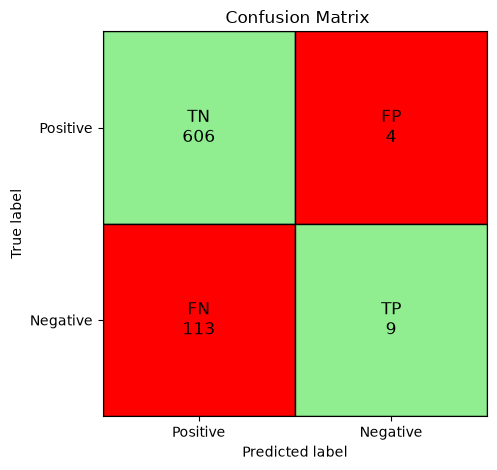

In [335]:
probs1 = log_model.predict(test_data)
preds1 = [1 if prob >= THRESHOLD else 0 for prob in probs1]
conf_matrix = confusion_matrix(test_data["TenYearCHD"], preds1)
plot_confusion_matrix(conf_matrix, "")

In [336]:
print(f"accuracy = {(conf_matrix[0, 0] + conf_matrix[1, 1]) / len(test_data)}")

accuracy = 0.8401639344262295


Worse than baseline...
Let's train a model using only predictors with low p-values (<0.05)

In [337]:
important_features = [
    "male",
    "age",
    "cigsPerDay",
    "totChol",
    "sysBP",
    "glucose",
    "TenYearCHD",
]

train_data2, test_data2 = train_test_split(
    df[important_features], test_size=TEST_RATIO, random_state=RANDOM_SEED
)

log_model2 = sm.formula.glm(  # generalized linear model
    formula=f"TenYearCHD ~ {' + '.join(df[important_features].columns.drop('TenYearCHD'))}",
    family=sm.families.Binomial(),  # target is binary (0/1)
    data=train_data2,
).fit()

print(log_model2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             TenYearCHD   No. Observations:                 2926
Model:                            GLM   Df Residuals:                     2919
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1089.8
Date:                Fri, 18 Sep 2026   Deviance:                       2179.6
Time:                        14:06:55   Pearson chi2:                 2.91e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.09141
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -9.2321      0.543    -16.989      0.0

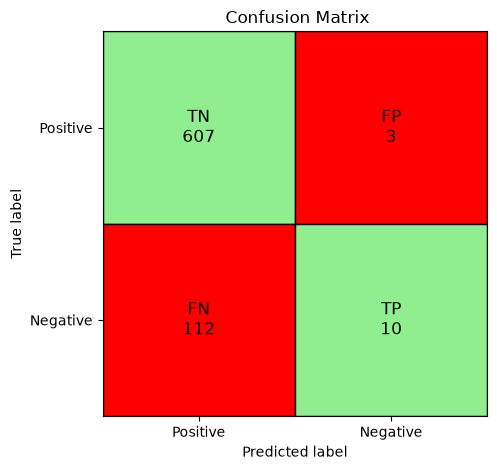

In [338]:
probs2 = log_model2.predict(test_data2)
preds2 = [1 if prob >= THRESHOLD else 0 for prob in probs2]
conf_matrix = confusion_matrix(test_data2["TenYearCHD"], preds2)
plot_confusion_matrix(conf_matrix, "")

In [339]:
print(f"accuracy = {(conf_matrix[0, 0] + conf_matrix[1, 1]) / len(test_data)}")

accuracy = 0.842896174863388


Note that the accuracy stayed about the same meaning that reducing predictors won't nessecarily increase accuracy but a simpler model will be more explainable. Can we get better results by varying the threshold?

### ROC curve - Receiver Operating Characteristic

Graph that shows how well a classification model performs at all possible classification thresholds.

- Y-axis: True Positive Rate (TPR)
- X-axis: False Positive Rate (FPR)

![ROC example](https://i0.wp.com/spotintelligence.com/wp-content/uploads/2024/06/roc-curve.jpg?fit=1200%2C675&ssl=1)

### AUC - Area Under the Curve:

Summarizes the overall performance of the model on a scale from 0.0 to 1.0.
Higher values indicate a stronger capacity to separate positive and negative classes.

Depending on the problem type we might want to change our threshold. For example here we might want less FN so we should lower the threshold.

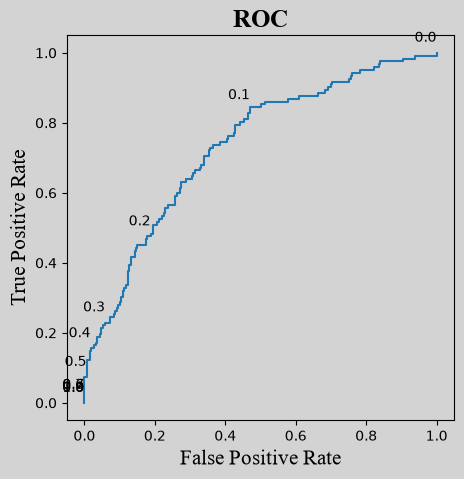

AUC: 0.732706261757592


In [340]:
# calculate roc curve and auc
fpr, tpr, thresholds = roc_curve(test_data["TenYearCHD"].to_list(), probs1)
roc_auc = auc(fpr, tpr)

# plot roc
plt.figure(figsize=(5, 5), facecolor=background_color)
plt.gca().set_facecolor(background_color)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate", fontdict=label_font)
plt.ylabel("True Positive Rate", fontdict=label_font)
plt.title("ROC", fontdict=title_font)

# add cutoffs
cutoffs = np.arange(0, 1.1, 0.1)
for c in cutoffs:
    plt.annotate(
        "%.1f" % c,
        (fpr[thresholds > c][-1], tpr[thresholds > c][-1]),
        textcoords="offset points",
        xytext=(-8, 8),
        ha="center",
        fontsize=10,
    )

plt.show()

print(f"AUC: {roc_auc}")

That means that our model is doing a good job

## Linear Regression

---

### Dataset Overview

In [341]:
wine = pd.read_csv(DATA_DIR / "wine.csv")
wine.head()

,Year,Price,WinterRain,AGST,HarvestRain,Age
0,1952,7.4950,600,17.1167,160,31
1,1953,8.0393,690,16.7333,80,30
2,1955,7.6858,502,17.1500,130,28
3,1957,6.9845,420,16.1333,110,26
4,1958,6.7772,582,16.4167,187,25


We will use scatter plots to get insights about linear relationships

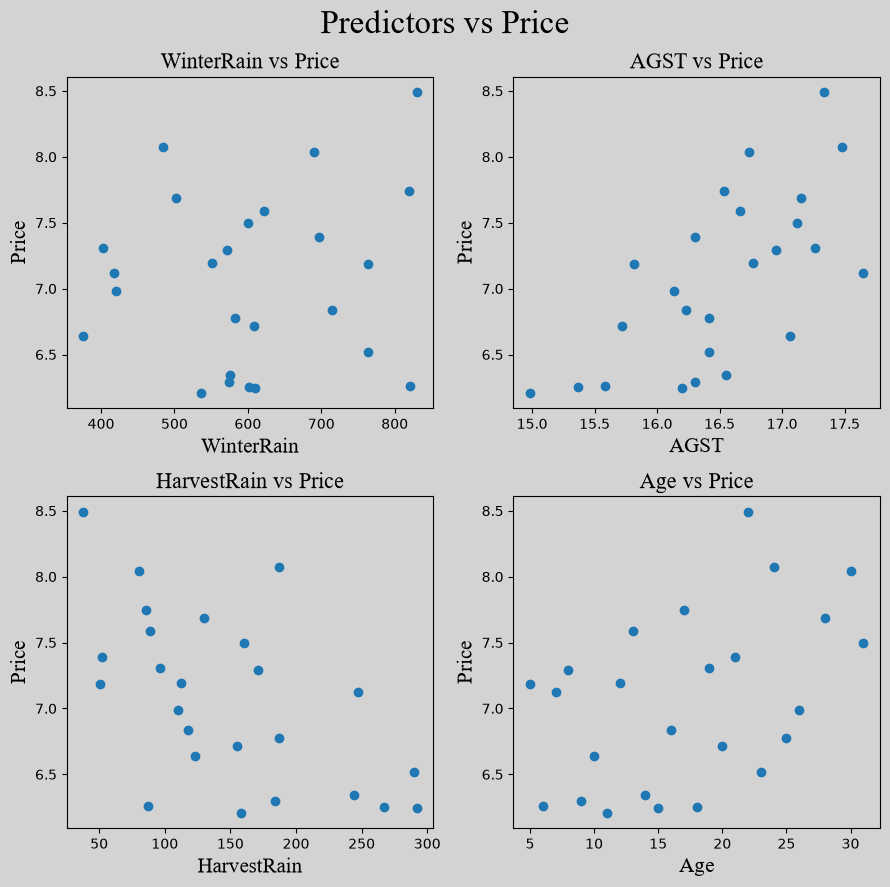

In [342]:
fig, axes = plt.subplots(2, 2, figsize=(9, 9), facecolor=background_color)
axes = axes.flatten()

predictors = wine.columns[2:]

for i in range(len(predictors)):
    axes[i].scatter(wine[predictors[i]], wine["Price"])

    axes[i].set_facecolor(background_color)
    axes[i].set_xlabel(predictors[i], fontdict=label_font)
    axes[i].set_ylabel("Price", fontdict=label_font)
    axes[i].set_title(
        f"{predictors[i]} vs Price", fontdict={"size": 16, "family": "Times New Roman"}
    )

plt.suptitle("Predictors vs Price", fontdict={"family": "Times New Roman"}, fontsize=24)
plt.tight_layout()
plt.show()

We see a linear relationship between (unclear) WinterRain (positive), AGST (positive), HarvestRain (negative), Age (positive) and Price but with a few outliers. Let's train a model with all predictors.

In [ ]:
x1 = wine[["WinterRain", "AGST", "HarvestRain", "Age"]]
x1 = sm.add_constant(x1)  # intercept

y = wine["Price"]

lin_model1 = sm.OLS(y, x1).fit()  # linear model

lin_model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     24.17
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           2.04e-07
Time:                        14:06:56   Log-Likelihood:                -2.1622
No. Observations:                  25   AIC:                             14.32
Df Residuals:                      20   BIC:                             20.42
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.4300      1.766     -1.942      0.066      -7.114       0.254
WinterRain      0.0011      0.001      2.120      0.047    1.73e-05       0.002
AGST            0.6072      0.099      6.152      0.000       0.401       0.813
HarvestRain    -0.0040      0.001     -4.652      0.000      -0.006      -0.002
Age             0.0239      0.008      2.956      0.008       0.007       0.041
==============================================================================
Omnibus:                        1.814   Durbin-Watson:                   2.797
Prob(Omnibus):                  0.404   Jarque-Bera (JB):                1.041
Skew:                           0.034   Prob(JB):                        0.594
Kurtosis:                       2.003   Cond. No.                     1.91e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.91e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Summary Explanation (2)

- *Model: OLS*: Ordinary Least Squares regression model
- **R-squared ($R^2$)**: *(coefficient of determination)*, is a statistical measure that shows the proportion of variance in a dependent variable that is explained by an independent variable or variables in a regression model. It tells us how well the data fits the regression line. The closer to 1 the better. Formula: $$R^{2} = 1 - \frac{\text{RSS}}{\text{TSS}}$$ where:
    - RSS (Residual Sum of Squares): The sum of squared residuals (unexplained error).
    - TSS (Total Sum of Squares): The total spread or variance in the actual data.

- **Adjusted R-squared ($\bar{R}^{2}$)**: modified version of R-squared that adjusts for the number of predictors (independent variables) in a regression model. Formula: $$\bar{R}^{2} = 1 - \left[\frac{\left(1 - R^{2}\right) \left(n - 1\right)}{n - k - 1}\right]$$ where:
    - n: The total sample size (number of data points).
    - k: The number of independent variables (predictors) in the model.

Comparison:

| Feature | Standard R-squared (R²) | Adjusted R-squared (R̄²)|
| --- | --- | --- |
| Purpose | Measures the percentage of variance explained by the model. | Measures the percentage of variance explained, penalized for unnecessary variables. |
| Reaction to New Variables | Always increases or stays the same. | Can increase or decrease.
| Usage Recommendation | Best used for simple linear regression (one predictor). | Best used for multiple linear regression (multiple predictors). |
| Value Range | Usually between 0 and 1. | Can be negative if the model is a very poor fit. |

- **t**: measure of how many standard deviations our coefficient estimate is far away from 0. We want it to be far away from zero as this would indicate we could reject the null hypothesis (used like p-value)

In [344]:
wine.drop(columns=["Year"]).corr()

,Price,WinterRain,AGST,HarvestRain,Age
Price,1.000000,0.136651,0.659563,-0.563322,0.447768
WinterRain,0.136651,1.000000,-0.321091,-0.275441,-0.016970
AGST,0.659563,-0.321091,1.000000,-0.064496,0.246916
HarvestRain,-0.563322,-0.275441,-0.064496,1.000000,-0.028009
Age,0.447768,-0.016970,0.246916,-0.028009,1.000000


### Correlation Matrix

Look at the numerical values (coefficients) in each cell, which range from -1 to +1, showing how strongly and in what direction two variables move together.

Ignore diagonal and note that it is symmetrical

Watch for **multicollinearity**: If two input predictors in the matrix have a very high correlation (e.g., above 0.85 or 0.90), they measure similar things, which can distort predictive models. Note that correlation ≠ Causation.

Here we observe low values that indicate low multicollinearity

Let's calculate R-squared from test data (adj-R-squared is in-sample metric)

In [371]:
wine_test = pd.read_csv(DATA_DIR / "wineTest.csv")

x1_test = wine_test[["WinterRain", "AGST", "HarvestRain", "Age"]]
x1_test = sm.add_constant(x1_test)  # intercept

y_test = wine_test["Price"]

SSE = np.sum((lin_model1.predict(x1_test) - y_test) ** 2)
SST = np.sum((y.mean() - y_test) ** 2)
r2 = 1 - SSE / SST
print(f"Test R-squared: {r2}")

Test R-squared: 0.7944277602631769
